<a href="https://colab.research.google.com/github/GuiSchling/Ising_Magnetism_sim/blob/main/IsingModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Estudo da Transição Magnética**

O estudo busca, através de métodos estocásticos, entender a transição de fase magnética, a temperatura de Curie e como a organização dos spins e a temperatura afetam esse comportamento macroscópico da matéria.

Exploramos o poder dos Métodos de Monte Carlo para simular a natureza aleatória dos spins, e utilizando metodos computacionais podemos calcular e vizualizar os efeitos macrocópicos.

O objetivo principal do estudo é simular e analisar o comportamento termôdinámico do Modelo de Ising e entender a transição de fase magnética. Para isso implementamos o algoritmo Metropolis, analisamos a formação dos domínios magnéticos e calculamos grandezas macroscópicas do sistema.





**O Modelo:**

Utilizamos uma matriz $N \times N$, onde cada elemento representa o momento magnético discreto (spin), que pode assumir apenas os valores $s = +1$ ou $s = -1$. Consideramos que cada spin interage unicamente com seus quatro vizinhos e também utilizamos condições períodicas de contorno, para que não haja bordas na grid, permitindo que todos os spins tenham quatro vizinhos.

Calculamos a energia do sistema utilizando o o Hamiltoniano de Ising:

$$E = -J \sum_{\langle i,j \rangle} s_i s_j$$

Onde $J$ é a constante de acoplamento, que consideramos $J > 0$ para que haja uma tendencia ferromagnética. Ao decorrer do estudo utilizamos, preferencialmente, $J = 1$



Para modelar o efeito caótico da temperatura, utilizamos o fator de Boltzmann:
$$P = e^{-\frac{\Delta E}{k_B T}}$$

Caso um valor aleatório seja maior que o fator de Boltzmann, invertemos o valor so spin.


A fim de evitar erros de precisão, na simulação usamos Temperatura e Magnetização com unidades adimensionais, para trazer os valores para a realidade utilizamos:

Para temperatura, em K:

$$T_{\text{SI}} = T_{\text{simulação}} \left( \frac{J}{k_B} \right)$$

Onde:
$J$: é energia de interação de troca, que depende do material
$k_B$: é a constante de Boltzmann, $k_B \approx 1.38 \times 10^{-23}$ J/K.

Para a magnetização em A/m:

$$M_{\text{SI}} = M_{\text{simulação}} \left( \frac{\mu}{a^3} \right)$$

Onde:
$\mu$: é o momento magnético de um único átomo (geralmente dado em Magnetons de Bohr, onde $1 \, \mu_B \approx 9.274 \times 10^{-24}$ J/T)

$a^3$: é o volume da célula unitária (o espaço tridimensional que cada spin ocupa na rede de átomos).

O valor crítico da Temperatura de Curie teórico $T_c \approx 2,269 \frac{J}{k_B}$ surge da equação:

$$\sinh\left(\frac{2J}{k_B T_c}\right) = 1$$




In [42]:
import numpy as np
import matplotlib.pyplot as plt

def inicializar_grid(N):
    """Inicializa a matriz de spins

    N: Dimensão da Matriz

    Retorna um np.array NxN com os spins aleatórios"""
    rng = np.random.default_rng()
    return rng.choice([1, -1], size=(N, N))

**Paramêtros:**

N: É a dimensão da grid

T: Temperatura

Sweeps: Unidade de tempo. Em cada sweep é realizado NxN tentativas de inversão de spin.

Termalização: Sweeps descartados do cálculo das médias de magnetização. Assim, tiramos os valores caóticos iniciais da média final.

J: É a constante de acomplamento, que consideramos maior que zero para que haja a tendência ferromagnética do material.



**A Função $ising()$:**

A função implementa o método de metrópolis, que consiste em, para cada sweep, escolher aleatóriamente um spin $s_{ij}$ e somar os spins de seus vizinhos $s_i s_j$. Multiplicando essa soma, pelo spin escolhido e por duas vezes a constante de acoplamento, obtemos a Variação de Energia do Sistema $ΔE$. Pela termodinâmica, o sistema tende a buscar a menor energia, logo, se a Energia do Sistema for menor ou igual a zero queremos inverter o spin. Mas, também consideramos a probabilidade do fator de Boltzmann não permitir essa inversão.



In [43]:


def ising(N, sweeps, T, termalizacao, J=1.0):
    """
    N: dimensão da grid
    sweeps: Quantas vezes foram realizadas NxN tentativas de inversão de spin, consideramos nossa medida de tempo.
    T: Temperatura.
    J: Constante de acoplamento.
    termalização: Número inicial de sweeps descartados para garantir que o sistema atinja o equilíbrio térmico antes da coleta de dados para a média.

    Retorna:

    grid: np.array com o estado final da grid
    grid_evolucao: lista com os estados da grid
    magnetizacao_evolucao: lista com a magnetização por sweep
    np.mean(magnetizacao_equilibrio): média da magnetizacao após a termalização


    """
    rng = np.random.default_rng()
    grid = inicializar_grid(N)

    grid_evolucao = [] #Lista para armazenar os estados da grid
    magnetizacao_evolucao = [] #Lista para armazenar a média de magnetização em cada sweep
    magnetizacao_equilibrio = [] #Lista para armazenar a média de magnetização em cada sweep, após a termalização


    for sweep in range(sweeps):
        #Em cada sweep, tentamos trocar o valor de N*N spins aleatórios
        for _ in range(N * N):
            i = rng.integers(0, N)
            j = rng.integers(0, N)
            spin = grid[i, j]

            vizinhos = (grid[(i + 1) % N, j] +
                        grid[(i - 1) % N, j] +
                        grid[i, (j + 1) % N] +
                        grid[i, (j - 1) % N])

            dE = 2 * J * spin * vizinhos

            #Critério de Metropolis
            if dE <= 0 or rng.random() < np.exp(-dE / T):
                grid[i, j] *= -1

        #Coleta de dados (uma vez por sweep)
        mag_atual = np.abs(np.mean(grid))
        magnetizacao_evolucao.append(mag_atual)

        if sweep % 10 == 0:
            grid_evolucao.append(grid.copy())

        #Só guardamos na média se já tiver passado do tempo de termalização
        if sweep >= termalizacao:
            magnetizacao_equilibrio.append(mag_atual)


    return grid,grid_evolucao, magnetizacao_evolucao, np.mean(magnetizacao_equilibrio)



**SIMULAÇÕES:**

Considerando uma grid 20x20, com 501 sweeps e Temperatura 1.5.

In [48]:
N = 32 #Dimensões da Matriz
sweeps = 1001
T = 1.5 #Temperatura
termalizacao = 200 #Tempo para estabilizar o magnetismo

grid,grid_evolucao, magnetizacao_total, media_mag = ising(N, sweeps, T, termalizacao)

Estados dos Spins:

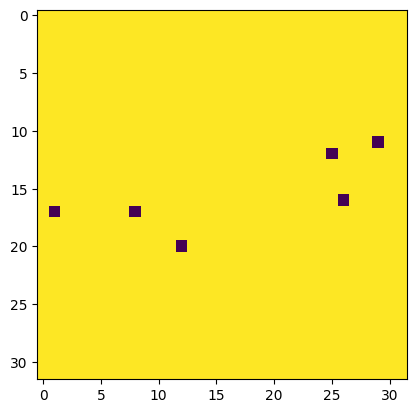

In [49]:
plt.imshow(grid,vmin=-1, vmax=1)

Verificamos que em uma temperatura baixa $T = 1.5$, o sistema tende a ordem dos spins, entrando no estado ferromagnético.

In [50]:
#animação mostrando a organização dos spins em função dos sweeps.

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_title(f"Grid de Spins (T = {T})")


im = ax.imshow(grid_evolucao[0],vmin=-1, vmax=1, animated=True)
ax.axis('off')


def atualizar(frame):
    im.set_data(grid_evolucao[frame])
    return [im]
ani = FuncAnimation(fig, atualizar, frames=len(grid_evolucao), interval=50, blit=True)
plt.close()

HTML(ani.to_jshtml())

Na animação, verificamos a transição ocorrendo a cada sweep. Podemos ver os spins formando ilhas até que o sistema se organize. Vemos também que o sistema se organiza em poucos sweeps, devido a baixa temperatura.

Magnetismo médio: 0.940889188936064
Magnetismo após termalização 0.9864037141073658


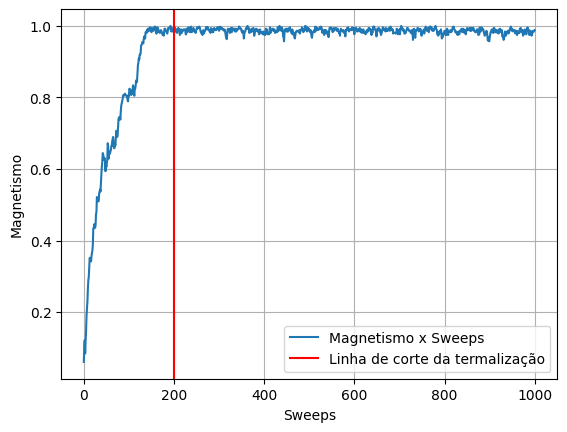

In [51]:

plt.plot(magnetizacao_total, label = "Magnetismo x Sweeps")
plt.ylabel("Magnetismo")
plt.xlabel("Sweeps")
plt.axvline(x=termalizacao, color='red', label="Linha de corte da termalização")
plt.legend()
plt.grid()

print(f"Magnetismo médio: {np.mean(magnetizacao_total)}")
print(f"Magnetismo após termalização {media_mag}")

O gráfico demonstra perfeitamente o comportamento esperado. No começo da simulação, ocorre um caos estocástico, que é estabilizado ao decorrer dos sweeps. Verificamos que a termalização estimada cortou quase perfeitamente a fase de estabilização.

**Analisamos também o comportamento da grid de spins em diferentes temperaturas:**

In [75]:
#Simulações por Temperatura

T = np.linspace(1.0,4.0,31)
N = 20
sweeps = 501
termalizacao = 100
t_critica = 2.269 #Temperatura crítica teórica para transição de fase


mag_media = [] #Lista para guardar a temperatura média após termalização em cada temperatura
grid_temp = [] #Lista para guardar o estado final da grid em cada temperatura
mag_temp = [] #Lista para guardar a evolução do magnetismo em cada temperatura
for t in T:
    grid,grid_evolucao, mag, m_mag = ising(N, sweeps, t, termalizacao)
    mag_media.append(m_mag)
    if t % 1 == 0 or t.round(2) == 2.3: #Salvamos a a grid e a magnetização apenas para temperaturas inteiras e para a temperatura crítica
        grid_temp.append(grid.copy())
        mag_temp.append(mag.copy())

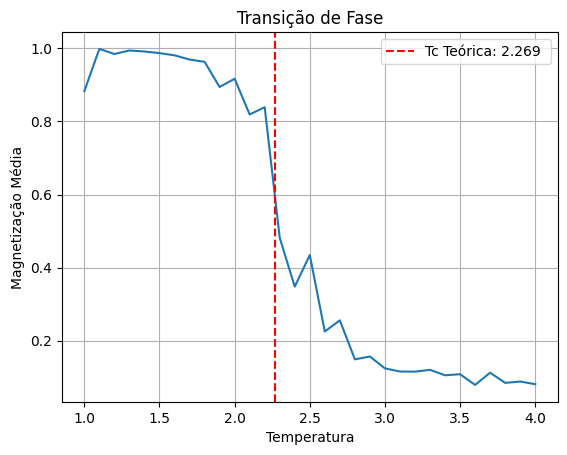

In [76]:
plt.plot(T, mag_media)
plt.xlabel("Temperatura")
plt.ylabel("Magnetização Média")
plt.axvline(x= t_critica, color='red', linestyle='--', label="Tc Teórica: 2.269 ")
plt.title("Transição de Fase")
plt.legend()
plt.grid()
plt.show()

No gráfico acima, verificamos que de fato acontece a transição de fase em torno da Temperatura Crítica. Podemos ver também algumas flutuações devido a natureza estocástica do algoritmo.

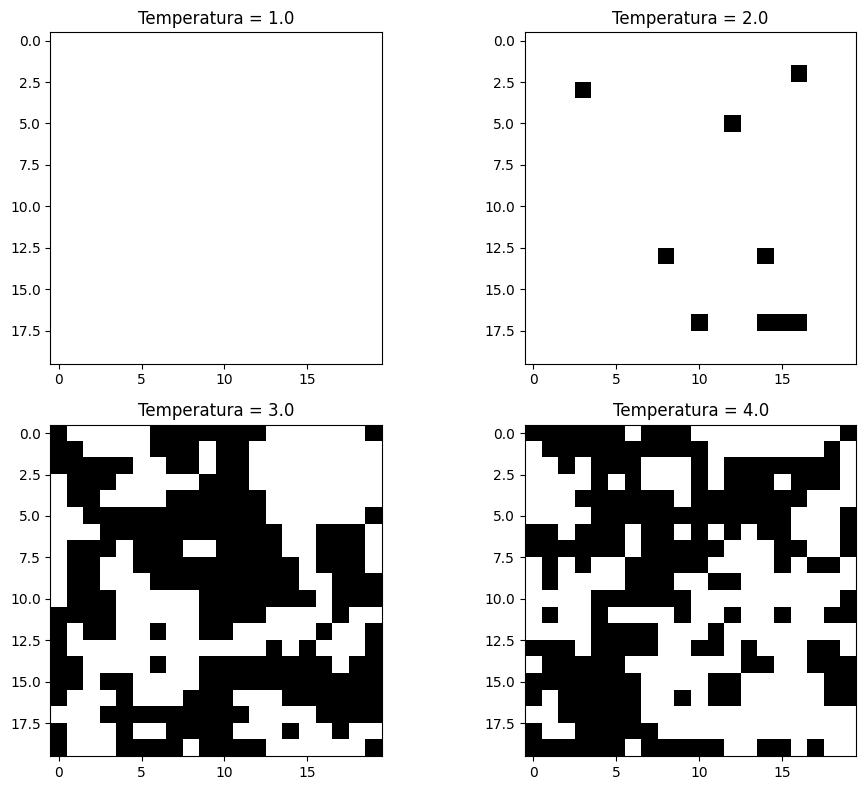

In [81]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

parametros_imagem = {'vmin': -1, 'vmax': 1, 'cmap': 'gray'}

axs[0, 0].imshow(grid_temp[0], **parametros_imagem)
axs[0, 0].set_title("Temperatura = 1.0")

axs[0, 1].imshow(grid_temp[1], **parametros_imagem)
axs[0, 1].set_title("Temperatura = 2.0")

axs[1, 0].imshow(grid_temp[3], **parametros_imagem)
axs[1, 0].set_title("Temperatura = 3.0")

axs[1, 1].imshow(grid_temp[4], **parametros_imagem)
axs[1, 1].set_title("Temperatura = 4.0")

plt.tight_layout()
plt.show()

Acima, vemos a diferença de "ordem" em diferentes temperaturas.

**Grid em $T \approx T_c$**

Text(0.5, 1.0, '$Temperatura \\approx 2.29$')

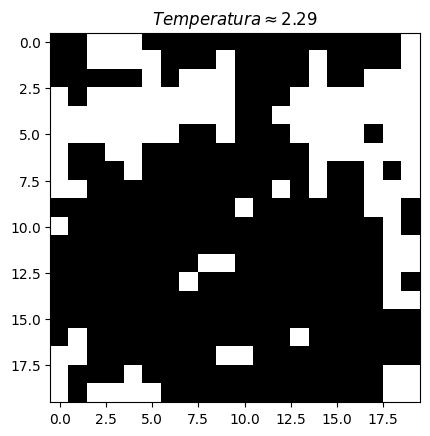

In [87]:
plt.imshow(grid_temp[2], **parametros_imagem)
plt.title(r"$Temperatura \approx 2.29$")



Na temperatura crítica, vemos que o sistema começa a tender a desordem. Podemos verificar também que o spin dominante foi aleatoriamente "flipado".

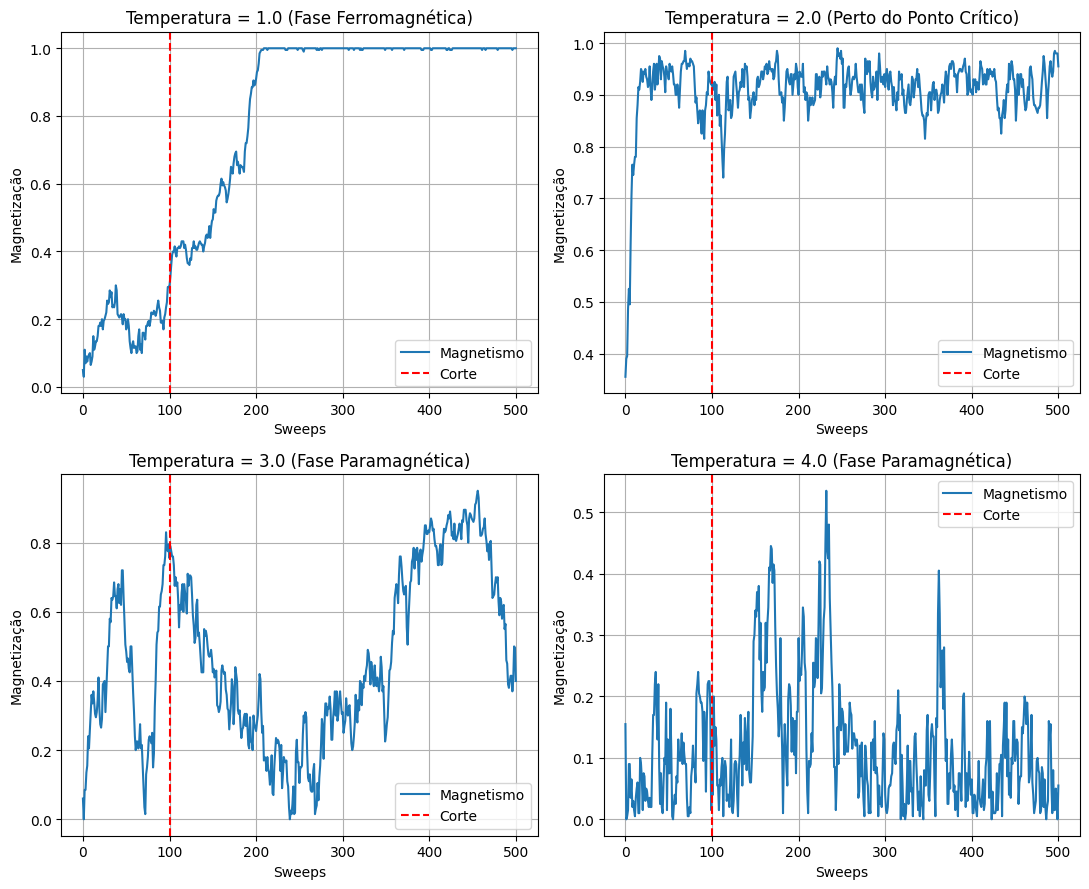

In [88]:
fig, axs = plt.subplots(2, 2, figsize=(11, 9))

axs[0, 0].plot(mag_temp[0], color='#1f77b4', label="Magnetismo")
axs[0, 0].axvline(x=termalizacao, color='red', linestyle='--', label="Corte")
axs[0, 0].set_title("Temperatura = 1.0 (Fase Ferromagnética)")
axs[0, 0].set_ylabel("Magnetização")
axs[0, 0].set_xlabel("Sweeps")
axs[0, 0].grid(True)
axs[0, 0].legend()

axs[0, 1].plot(mag_temp[1], color='#1f77b4', label="Magnetismo")
axs[0, 1].axvline(x=termalizacao, color='red', linestyle='--', label="Corte")
axs[0, 1].set_title("Temperatura = 2.0 (Perto do Ponto Crítico)")
axs[0, 1].set_ylabel("Magnetização")
axs[0, 1].set_xlabel("Sweeps")
axs[0, 1].grid(True)
axs[0, 1].legend()

axs[1, 0].plot(mag_temp[2], color='#1f77b4', label="Magnetismo")
axs[1, 0].axvline(x=termalizacao, color='red', linestyle='--', label="Corte")
axs[1, 0].set_title("Temperatura = 3.0 (Fase Paramagnética)")
axs[1, 0].set_ylabel("Magnetização")
axs[1, 0].set_xlabel("Sweeps")
axs[1, 0].grid(True)
axs[1, 0].legend()


axs[1, 1].plot(mag_temp[3], color='#1f77b4', label="Magnetismo")
axs[1, 1].axvline(x=termalizacao, color='red', linestyle='--', label="Corte")
axs[1, 1].set_title("Temperatura = 4.0 (Fase Paramagnética)")
axs[1, 1].set_ylabel("Magnetização")
axs[1, 1].set_xlabel("Sweeps")
axs[1, 1].grid(True)
axs[1, 1].legend()

plt.tight_layout()
plt.show()

Os gráficos evidenciam ainda mais a desordem magnética em temperaturas maiores. Vemos também que a termalização estimada não foi precisa para $T=1$, indicando que a aleatoriedade causou uma demora maior na estabilização do sistema nessa temperatura.

**Considerações Finais:**

Os parâmetros foram escolhidos considerando, principalmente, o custo computacional e tempo para as simulações. Verificamos que o aumento na quantidade de $sweeps$ tende a diminuir ruídos, pois aumenta a amostra estatística. Aumentando a dimensão $N$ da nossa grid, confirmamos que para ter uma transição abrupta $T = T_c$ precisaria de $N \to \infty$. Além disso, aumentar $N$ demanda aumentar a quantidade de $sweeps$, tornando a simulação muito mais lenta.

A mudança da estimativa de $Termalização$ torna nossa média maior ou menor.

A constante $J$ não muda de forma físicamente considerável o sistema, se mantida acima de zero. Apenas muda a escala da temperatura crítica.

**Conclusão**

Precisamos, também, considerar limitações intrísecas do modelo.

* O modelo simplifica os spins entre $-1$ ou $1$, quando o modelo de Heisenberg apresenta spins como vetores no espaço.
* O Hamiltoniano modela apenas interações entre vizinhos, ignorando possiveis interações de maior alcance
* Trabalhamos com um valor finito de $N$, portanto não podemos verificar a quedra brusca esperada na $T_c$
* Simular grandes quantidades de $N$ ou $sweeps$ exige bastante tempo, pois a quantidade de iterações é $sweeps \times N \times N$, o que limita os valores para esses parâmetros.

Apesar de tais limitações, o modelo é sucedido em demonstrar a transição de fase prevista na $T_c$, além de tornar possivel vizualizar, de maneira consistente com o esperado, a organização dos spins em relação a cada temperatura. Consideramos o algoritmo Metrópolis eficiente em modelar o sistema trabalhado.




